## 1. Configuração dos experimentos

In [31]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Carregamento e preparação dos dados

In [32]:
RAIZ = next(
    pasta for pasta in [Path.cwd(), *Path.cwd().parents]
    if (pasta / 'dataset').is_dir()
)

dados = {}

for abordagem in ['abordagem_1', 'abordagem_2']:
    pasta = RAIZ / 'dataset' / abordagem

    treino = pd.read_csv(pasta / 'treino.csv')
    teste = pd.read_csv(pasta / 'teste.csv')
    validacao = pd.read_csv(pasta / 'validacao.csv')

    dados[abordagem] = {
        'treino': treino,
        'teste': teste,
        'validacao': validacao
    }

In [33]:
for abordagem in dados:
    treino = dados[abordagem]['treino']

    print(f'\n{abordagem.upper()}')
    print('Distribuição das classes no treinamento:')
    print(treino['classe'].value_counts())


ABORDAGEM_1
Distribuição das classes no treinamento:
classe
X venceu    140
Tem jogo    140
O venceu    140
Empate      140
Name: count, dtype: int64

ABORDAGEM_2
Distribuição das classes no treinamento:
classe
X venceu    140
Tem jogo    140
O venceu    140
Empate      140
Name: count, dtype: int64


## 3. Treinamento e validação do MLP

In [34]:
for abordagem in dados:
    treino = dados[abordagem]['treino']
    teste = dados[abordagem]['teste']
    validacao = dados[abordagem]['validacao']

    dados[abordagem]['x_treino'] = treino.drop(columns=['classe']).astype(int)
    dados[abordagem]['y_treino'] = treino['classe']

    dados[abordagem]['x_teste'] = teste.drop(columns=['classe']).astype(int)
    dados[abordagem]['y_teste'] = teste['classe']

    dados[abordagem]['x_validacao'] = validacao.drop(columns=['classe']).astype(int)
    dados[abordagem]['y_validacao'] = validacao['classe']

In [35]:
resultados = {}
modelos = {}
predicoes = {}
dados_modelos = {}

def avaliar(nome, modelo):

    for abordagem in ['abordagem_1', 'abordagem_2']:

        x_treino = dados[abordagem]['x_treino']
        y_treino = dados[abordagem]['y_treino']
        x_validacao = dados[abordagem]['x_validacao']
        y_validacao = dados[abordagem]['y_validacao']

        modelo_atual = Pipeline([
            ('normalizacao', StandardScaler()),
            ('mlp', clone(modelo))
        ])

        modelo_atual.fit(x_treino, y_treino)
        y_pred = modelo_atual.predict(x_validacao)

        chave = f"{nome}_{abordagem.replace('abordagem_', 'ab')}"

        resultados[chave] = {
            'acuracia': accuracy_score(y_validacao, y_pred),
            'precisao': precision_score(
                y_validacao, y_pred, average='macro', zero_division=0
            ),
            'recall': recall_score(
                y_validacao, y_pred, average='macro', zero_division=0
            ),
            'f1': f1_score(
                y_validacao, y_pred, average='macro', zero_division=0
            ),
        }

        modelos[chave] = modelo_atual
        predicoes[chave] = y_pred
        dados_modelos[chave] = dados[abordagem]

        print(f"{chave} | F1 macro = {resultados[chave]['f1']:.4f}")

    return modelo_atual, y_pred

In [36]:
avaliar('1',
        MLPClassifier(hidden_layer_sizes=(10,),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.001,
                   momentum=0.1,
                   max_iter=3000,
                   random_state=42)
        )

1_ab1 | F1 macro = 0.7667
1_ab2 | F1 macro = 0.9350


(Pipeline(steps=[('normalizacao', StandardScaler()),
                 ('mlp',
                  MLPClassifier(hidden_layer_sizes=(10,), max_iter=3000,
                                momentum=0.1, random_state=42))]),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'Empate', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'O venceu', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X ven

In [37]:
avaliar('2',
        MLPClassifier(hidden_layer_sizes=(16,),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.001,
                   momentum=0.1,
                   max_iter=3000,
                   random_state=42)
        )

2_ab1 | F1 macro = 0.5681
2_ab2 | F1 macro = 0.9517


(Pipeline(steps=[('normalizacao', StandardScaler()),
                 ('mlp',
                  MLPClassifier(hidden_layer_sizes=(16,), max_iter=3000,
                                momentum=0.1, random_state=42))]),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'Tem jogo',
        'O venceu', 'X venceu', 'Empate', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X ven

In [38]:
avaliar('3',
        MLPClassifier(hidden_layer_sizes=(32,),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.001,
                   momentum=0.1,
                   max_iter=3000,
                   random_state=42)
        )

3_ab1 | F1 macro = 0.7827
3_ab2 | F1 macro = 0.9350


(Pipeline(steps=[('normalizacao', StandardScaler()),
                 ('mlp',
                  MLPClassifier(hidden_layer_sizes=(32,), max_iter=3000,
                                momentum=0.1, random_state=42))]),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'Empate', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'O venceu', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X ven

In [39]:
avaliar('4',
        MLPClassifier(hidden_layer_sizes=(64,),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.001,
                   momentum=0.1,
                   max_iter=3000,
                   random_state=42)
        )

4_ab1 | F1 macro = 0.7760
4_ab2 | F1 macro = 0.9434


(Pipeline(steps=[('normalizacao', StandardScaler()),
                 ('mlp',
                  MLPClassifier(hidden_layer_sizes=(64,), max_iter=3000,
                                momentum=0.1, random_state=42))]),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'Empate', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X ven

In [40]:
avaliar('5',
        MLPClassifier(hidden_layer_sizes=(32,16),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.001,
                   momentum=0.1,
                   max_iter=3000,
                   random_state=42)
        )

5_ab1 | F1 macro = 0.7329
5_ab2 | F1 macro = 0.9833


(Pipeline(steps=[('normalizacao', StandardScaler()),
                 ('mlp',
                  MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=3000,
                                momentum=0.1, random_state=42))]),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', '

In [41]:
def graficos(nome, y_real, y_pred, conjunto):
    modelo = modelos[nome].named_steps['mlp']
    rotulo = f"{nome} ({conjunto})"

    # 1) Matriz de confusão
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(y_real, y_pred, cmap='Blues', ax=ax)
    ax.set_title(f"Matriz de confusão – {rotulo}")
    plt.show()

    # 2) Quantidade por classe: real vs predito
    classes = np.unique(np.concatenate([np.asarray(y_real), y_pred]))
    real = [np.sum(np.asarray(y_real) == c) for c in classes]
    pred = [np.sum(y_pred == c) for c in classes]
    x = np.arange(len(classes))

    plt.figure(figsize=(8, 5))
    plt.bar(x - 0.2, real, width=0.4, label="Real", color="blue", alpha=0.7)
    plt.bar(x + 0.2, pred, width=0.4, label="Predito", color="red", alpha=0.7)
    plt.xticks(x, classes)
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.title(f"Distribuição das classes – {rotulo}")
    plt.legend()
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.show()

    # 3) Curva de perda do treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(modelo.loss_curve_, color="purple")
    plt.xlabel("Época")
    plt.ylabel("Perda (loss)")
    plt.title(f"Curva de aprendizado – {rotulo}")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    # Relatório por classe
    print(f"Relatório – {rotulo}")
    print(classification_report(y_real, y_pred, zero_division=0))

    # Estrutura da rede
    print("Camadas ocultas:", modelo.hidden_layer_sizes)
    print("Camadas totais (entrada + ocultas + saída):", len(modelo.coefs_) + 1)
    for i, (w, b) in enumerate(zip(modelo.coefs_, modelo.intercepts_)):
        print(f"Camada {i} → {i+1}: pesos {w.shape}, bias {b.shape}")

### 3.1 Justificativa dos parâmetros

- **Arquiteturas (10, 16, 32, 64 e 32+16 neurônios):** o problema tem só 9 entradas e 4 classes, então começamos com uma rede pequena e aumentamos a capacidade para ver se o desempenho melhora ou se o modelo começa a decorar o treino. A configuração com duas camadas (32, 16) testa se uma representação mais profunda ajuda.
- **`activation='relu'`:** padrão para camadas ocultas; treina rápido e evita o problema de gradiente que desaparece das funções sigmoide/tanh. Foram realizados testes com toda as opções e a relu se saiu melhor. 
- **`solver='adam'`:** ajusta a taxa de aprendizado por parâmetro e costuma convergir bem sem muito ajuste fino, o que é adequado para comparar arquiteturas de forma justa.
- **`learning_rate_init=0.001`:** valor padrão recomendado para o Adam; passos menores dão um treino mais estável. Testes realizados com taxas maiores tiveram um resultado pior. 
- **`max_iter=3000`:** limite alto para garantir convergência. O sklearn para antes se a perda parar de melhorar. Ao realizar os testes inicias com 1000, o modelo não conseguia terminar de aprender antes de finalizar as épocas, por isso foi aumentado. 
- **`random_state=42`:** fixa a inicialização dos pesos para que os resultados sejam reproduzíveis e as comparações entre modelos sejam justas.
- **`momentum`:** na prática ele é ignorado com Adam, foi testado com outros métodos. 
- **Critério de escolha (F1-macro):** dá o mesmo peso a todas as classes. Com o *Empate* tão raro, a acurácia sozinha esconderia um modelo que nunca acerta essa classe.
- **StandardScaler**: coloca todos os atributos na mesma escala (média 0, desvio 1). Na abordagem 2 isso é importante, porque os atributos têm escalas diferentes. casas_vazias vai de 0 a 9, e ocupada_* é só 0 ou 1. Sem normalizar, os atributos com valores maiores dominam o ajuste dos pesos da rede.

### 3.2 Análise de overfitting

Análise de overfitting
       f1_treino  f1_validacao  diferenca
1_ab1     0.8642        0.7667     0.0975
1_ab2     0.9875        0.9350     0.0525
2_ab1     0.9435        0.5681     0.3755
2_ab2     0.9875        0.9517     0.0358
3_ab1     0.9982        0.7827     0.2155
3_ab2     0.9893        0.9350     0.0542
4_ab1     1.0000        0.7760     0.2240
4_ab2     0.9911        0.9434     0.0477
5_ab1     1.0000        0.7329     0.2671
5_ab2     0.9929        0.9833     0.0095


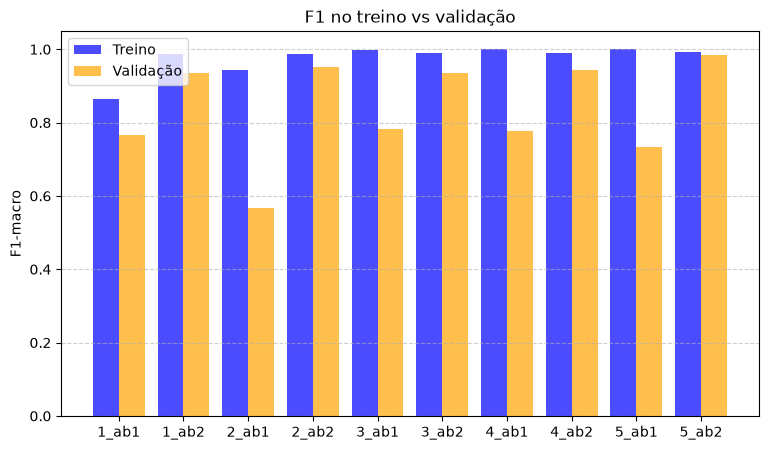

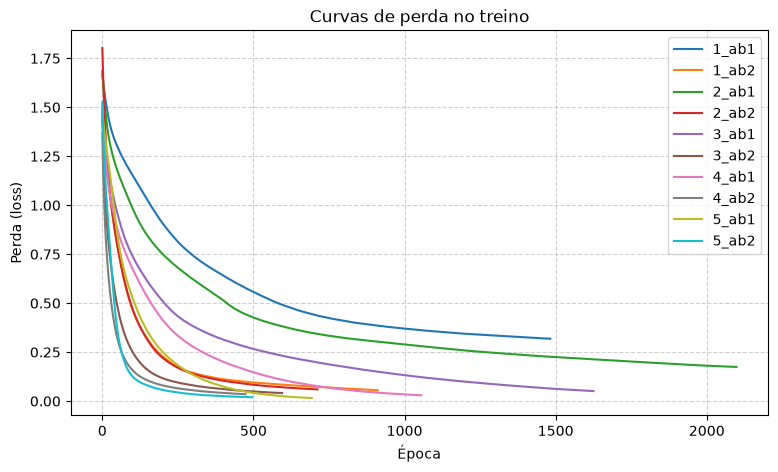

In [42]:
# F1 no treino vs F1 na validação
overfitting = {}
for nome, modelo in modelos.items():
    x_treino = dados_modelos[nome]['x_treino']
    y_treino = dados_modelos[nome]['y_treino']

    y_pred_treino = modelo.predict(x_treino)

    f1_treino = f1_score(y_treino, y_pred_treino, average='macro', zero_division=0)
    f1_val = resultados[nome]['f1']
    overfitting[nome] = {
        'f1_treino': f1_treino,
        'f1_validacao': f1_val,
        'diferenca': f1_treino - f1_val,
    }

df_overfitting = pd.DataFrame(overfitting).T.round(4)
print('Análise de overfitting')
print(df_overfitting)

# Gráfico: F1 treino vs validação
x = np.arange(len(df_overfitting))
plt.figure(figsize=(9, 5))
plt.bar(x - 0.2, df_overfitting['f1_treino'], width=0.4, label="Treino", color="blue", alpha=0.7)
plt.bar(x + 0.2, df_overfitting['f1_validacao'], width=0.4, label="Validação", color="orange", alpha=0.7)
plt.xticks(x, df_overfitting.index)
plt.ylabel("F1-macro")
plt.ylim(0, 1.05)
plt.title("F1 no treino vs validação")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.show()

# Curvas de perda de todos os modelos juntas
plt.figure(figsize=(9, 5))
for nome, modelo in modelos.items():
 plt.plot(modelo.named_steps['mlp'].loss_curve_, label=nome)
plt.xlabel("Época")
plt.ylabel("Perda (loss)")
plt.title("Curvas de perda no treino")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### 3.3 Interpretação dos resultados de overfitting

Abordagem 1 (tabuleiro cru): o padrão da versão anterior se repete.

- O mlp_1 tem underfitting: F1 de treino de 0,86, e a perda para em torno de 0,32 depois de cerca de 1.500 épocas.
- O mlp_3 (32 neurônios) tem a melhor validação (0,78).
- O mlp_4 e o mlp_5 chegam a F1 = 1,0 no treino, mas a validação cai (0,78 e 0,73). A diferença entre treino e validação passa de 0,2: mais capacidade, mais overfitting.
- O mlp_2 é um ponto fora da curva: tem a maior diferença (0,38) e a pior validação (0,57), pior até que o mlp_1, que é menor. Isso mostra como o treino na abordagem 1 é instável. Vale conferir no classification_report se ele deixou de prever alguma classe, provavelmente o Empate.

Abordagem 2 (atributos derivados): o comportamento é bem diferente.

- Todos os modelos têm diferença entre treino e validação abaixo de 0,06, ou seja, pouco overfitting.
- Aqui, mais capacidade não piorou. O mlp_5, o maior, teve a melhor validação (0,98) e a menor diferença (0,01). Com bons atributos, a rede aprende o padrão real em vez de decorar tabuleiros.

Curvas de perda:

- Na abordagem 2, todas convergem mais rápido (em geral entre 500 e 900 épocas) e chegam a perdas mais baixas.
- Na abordagem 1, as curvas são mais lentas, e os modelos pequenos param em perdas altas: cerca de 0,32 no mlp_1 e 0,17 no mlp_2, depois de 1.500 a 2.100 épocas.

## 4. Resultados dos experimentos

### 4.1 Resultados na Validação

-----
Tabela de resultados
       acuracia  precisao  recall      f1
5_ab2    0.9785    0.9844  0.9833  0.9833
2_ab2    0.9785    0.9294  0.9833  0.9517
4_ab2    0.9677    0.9219  0.9750  0.9434
1_ab2    0.9570    0.9148  0.9667  0.9350
3_ab2    0.9570    0.9128  0.9667  0.9350
3_ab1    0.8172    0.7830  0.7833  0.7827
4_ab1    0.8602    0.8954  0.7417  0.7760
1_ab1    0.7419    0.7426  0.8000  0.7667
5_ab1    0.8495    0.7327  0.7333  0.7329
2_ab1    0.7419    0.5630  0.5750  0.5681
-----


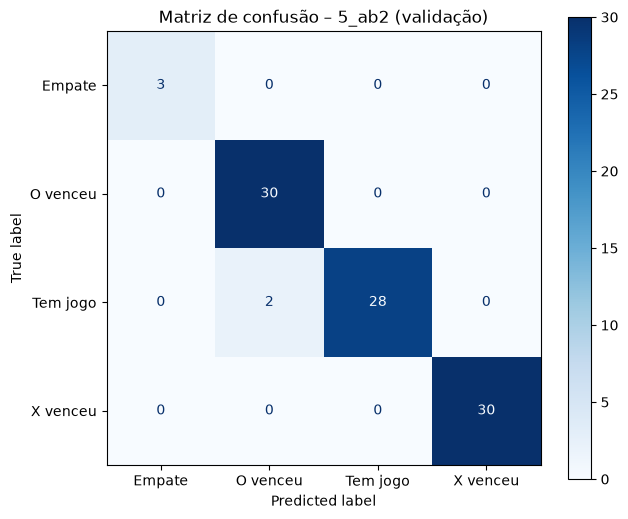

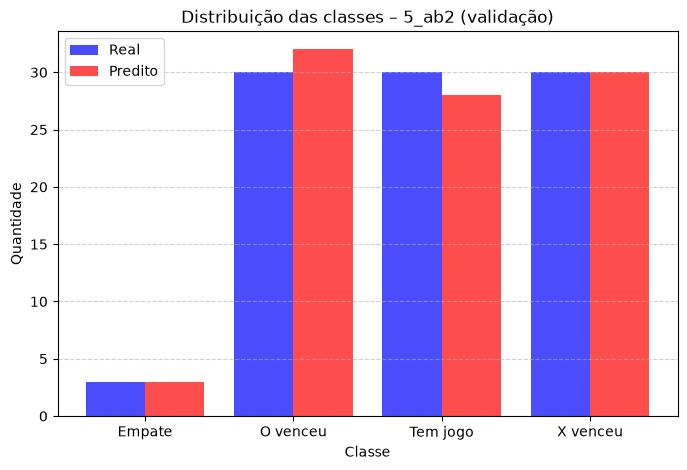

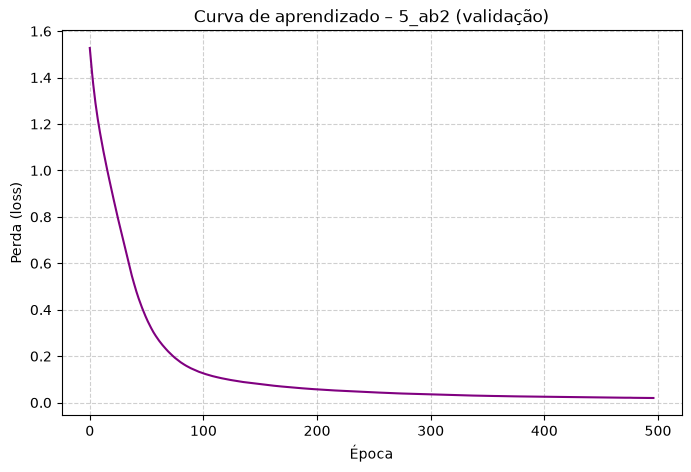

Relatório – 5_ab2 (validação)
              precision    recall  f1-score   support

      Empate       1.00      1.00      1.00         3
    O venceu       0.94      1.00      0.97        30
    Tem jogo       1.00      0.93      0.97        30
    X venceu       1.00      1.00      1.00        30

    accuracy                           0.98        93
   macro avg       0.98      0.98      0.98        93
weighted avg       0.98      0.98      0.98        93

Camadas ocultas: (32, 16)
Camadas totais (entrada + ocultas + saída): 4
Camada 0 → 1: pesos (15, 32), bias (32,)
Camada 1 → 2: pesos (32, 16), bias (16,)
Camada 2 → 3: pesos (16, 4), bias (4,)


In [43]:
print("-----")
print('Tabela de resultados')
df = pd.DataFrame(resultados).T.round(4)
print(df.sort_values('f1', ascending=False))
print('-----')

melhor = df['f1'].idxmax()
y_validacao = dados_modelos[melhor]['y_validacao']
graficos(melhor, y_validacao, predicoes[melhor], 'validação')


### 4.2 Gráfico comparativo

- Na abordagem 1, alguns modelos têm acurácia bem maior que o F1. O mlp_4 tem acurácia de 0,86 e F1 de 0,78, e o mlp_5 tem 0,85 e 0,73. Isso é sinal de que vão bem nas classes grandes e mal no Empate, e é um bom exemplo de por que o F1-macro foi escolhido como critério.
- Na abordagem 2, o mlp_5 é o mais equilibrado, com as 4 métricas em torno de 0,98. Nos demais, a precisão (cerca de 0,92) fica abaixo do recall (cerca de 0,97), o que indica que alguma classe recebe previsões a mais. Com só 3 empates na validação, um único falso Empate já derruba bastante a precisão média. Confira no relatório.

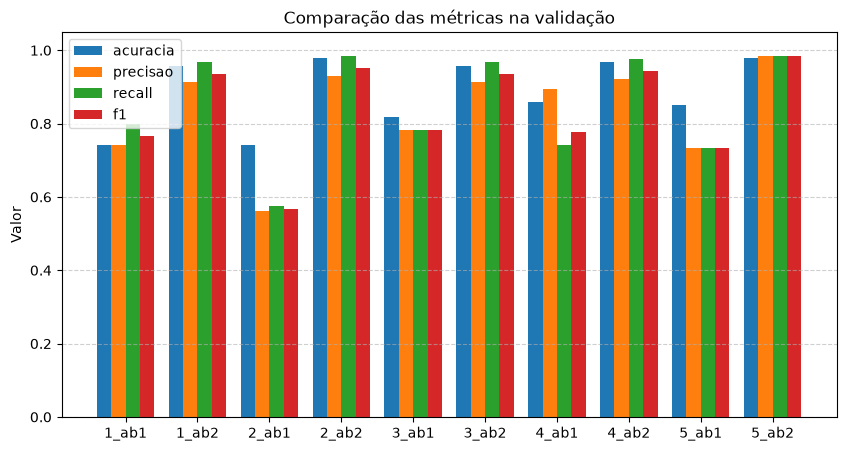

In [44]:
# Comparação das 4 métricas na validação para cada modelo
metricas = ['acuracia', 'precisao', 'recall', 'f1']
x = np.arange(len(df))
largura = 0.2

plt.figure(figsize=(10, 5))
for i, metrica in enumerate(metricas):
    plt.bar(x + (i - 1.5) * largura, df[metrica], width=largura, label=metrica)
plt.xticks(x, df.index)
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.title("Comparação das métricas na validação")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.show()

### 4.3 Avaliação no conjunto de teste

-----
Resultado final no teste – 5_ab2
acuracia    0.9355
precisao    0.9536
recall      0.9500
f1          0.9498
dtype: float64
-----


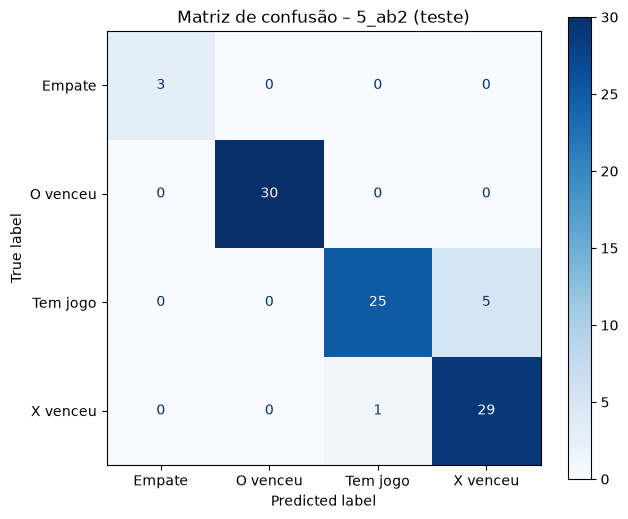

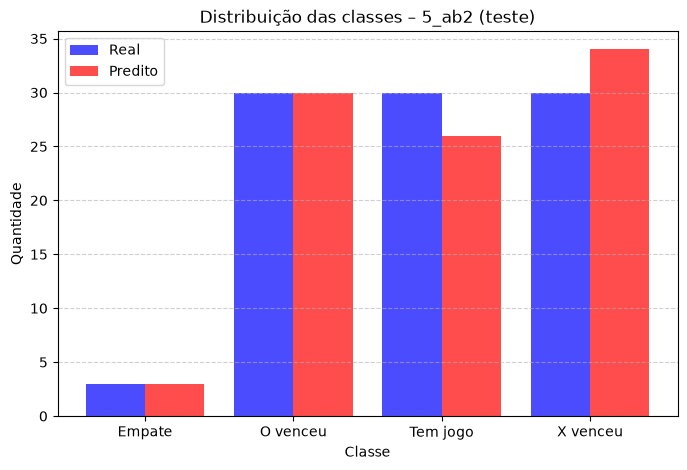

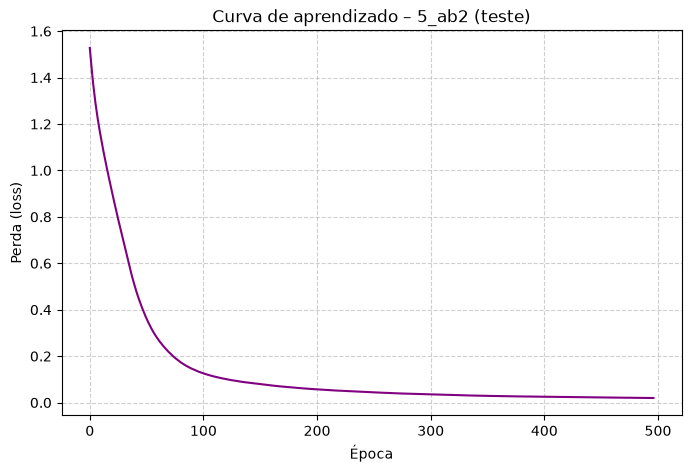

Relatório – 5_ab2 (teste)
              precision    recall  f1-score   support

      Empate       1.00      1.00      1.00         3
    O venceu       1.00      1.00      1.00        30
    Tem jogo       0.96      0.83      0.89        30
    X venceu       0.85      0.97      0.91        30

    accuracy                           0.94        93
   macro avg       0.95      0.95      0.95        93
weighted avg       0.94      0.94      0.94        93

Camadas ocultas: (32, 16)
Camadas totais (entrada + ocultas + saída): 4
Camada 0 → 1: pesos (15, 32), bias (32,)
Camada 1 → 2: pesos (32, 16), bias (16,)
Camada 2 → 3: pesos (16, 4), bias (4,)


In [45]:
# Avaliação final no TESTE
modelo_final = modelos[melhor]

x_teste = dados_modelos[melhor]['x_teste']
y_teste = dados_modelos[melhor]['y_teste']

y_pred_teste = modelo_final.predict(x_teste)

resultado_teste = {
    'acuracia': accuracy_score(y_teste, y_pred_teste),
    'precisao': precision_score(y_teste, y_pred_teste, average='macro', zero_division=0),
    'recall':   recall_score(y_teste, y_pred_teste, average='macro', zero_division=0),
    'f1':       f1_score(y_teste, y_pred_teste, average='macro', zero_division=0),
}

print('-----')
print(f'Resultado final no teste – {melhor}')
print(pd.Series(resultado_teste).round(4))
print('-----')

graficos(melhor, y_teste, y_pred_teste, 'teste')

### 4.4 Análise dos resultados

- O pré-processamento foi o fator mais importante. A melhor validação passou de 0,78 (abordagem 1) para 0,98 (abordagem 2).
- No teste, o mlp_5_abordagem_2 teve F1 de 0,95 e acurácia de 0,94. Houve uma queda de 3 a 4 pontos em relação à validação (0,98), maior que a da Random Forest, mas ainda um bom resultado.
- A capacidade ideal depende da abordagem: 32 neurônios na abordagem 1 e a maior rede (32+16) na abordagem 2.

## 5. Conclusão

A abordagem de pré-processamento foi o fator mais importante. Com o tabuleiro cru (abordagem 1), a melhor validação foi de 0,78. Nessa abordagem também houve overfitting forte nas redes maiores, com diferença de até 0,27 entre treino e validação, e resultados instáveis, como o do mlp_2. Com os atributos derivados (abordagem 2), todos os modelos passaram de 0,93 na validação, com diferença entre treino e validação abaixo de 0,06. Além disso, a capacidade ideal da rede mudou conforme a abordagem. Na abordagem 1, aumentar a rede além de 32 neurônios só aumentou o overfitting. Na abordagem 2, a maior rede foi a melhor, porque os atributos já resumem as regras do jogo e a rede aprende o padrão em vez de decorar tabuleiros.